In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors

%matplotlib inline

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/BBBP.csv")

print(f"Aantal rijen: {len(df)}")
print(f"Kolommen: {df.columns.tolist()}")
df.head()

Aantal rijen: 2050
Kolommen: ['num', 'name', 'p_np', 'smiles']


,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   num     2050 non-null   int64
 1   name    2050 non-null   str  
 2   p_np    2050 non-null   int64
 3   smiles  2050 non-null   str  
dtypes: int64(2), str(2)
memory usage: 64.2 KB


p_np
1    1567
0     483
Name: count, dtype: int64

Percentage positief: 76.4%


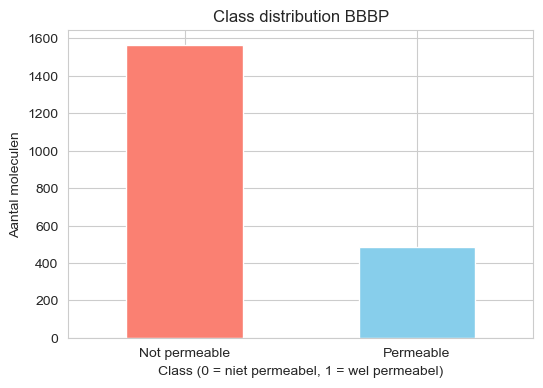

In [4]:
# BBBP heeft een kolom 'p_np' (permeable / not permeable)
# 1 = kan de BBB passeren, 0 = kan dat niet
class_counts = df['p_np'].value_counts()
print(class_counts)
print(f"\nPercentage positief: {class_counts[1] / len(df) * 100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
class_counts.plot(kind='bar', ax=ax, color=['salmon', 'skyblue'])
ax.set_xlabel("Class (0 = niet permeabel, 1 = wel permeabel)")
ax.set_ylabel("Aantal moleculen")
ax.set_title("Class distribution BBBP")
ax.set_xticklabels(['Not permeable', 'Permeable'], rotation=0)
plt.show()

count    2050.000000
mean       51.474146
std        30.620659
min         3.000000
25%        33.000000
50%        45.000000
75%        61.000000
max       400.000000
Name: smiles_length, dtype: float64


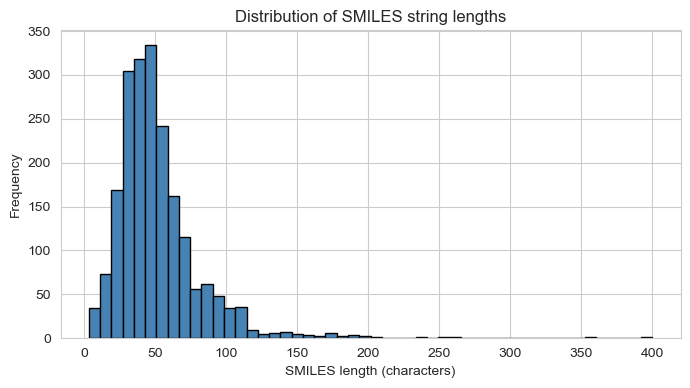

In [ ]:
# Lengte van SMILES strings 
df['smiles_length'] = df['smiles'].str.len()

print(df['smiles_length'].describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['smiles_length'], bins=50, color='steelblue', edgecolor='black')
ax.set_xlabel("SMILES length (characters)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of SMILES string lengths")
plt.show()

In [ ]:
# Check op geldigheid van SMILES strings
def is_valid_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None

df['valid'] = df['smiles'].apply(is_valid_smiles)

n_invalid = (~df['valid']).sum()
print(f"Aantal ongeldige SMILES: {n_invalid}")
print(f"Aantal geldige SMILES: {df['valid'].sum()}")

if n_invalid > 0:
    print("\nVoorbeelden van ongeldige SMILES:")
    print(df[~df['valid']]['smiles'].head())

Aantal ongeldige SMILES: 11
Aantal geldige SMILES: 2039

Voorbeelden van ongeldige SMILES:
59     O=N([O-])C1=C(CN=C1NCCSCc2ncccc2)Cc3ccccc3
61       c1(nc(NC(N)=[NH2])sc1)CSCCNC(=[NH]C#N)NC
391                        Cc1nc(sc1)\[NH]=C(\N)N
614     s1cc(CSCCN\C(NC)=[NH]\C#N)nc1\[NH]=C(\N)N
642           c1c(c(ncc1)CSCCN\C(=[NH]\C#N)NCC)Br
Name: smiles, dtype: str


[16:02:58] Explicit valence for atom # 1 N, 4, is greater than permitted
[16:02:58] WARNING: not removing hydrogen atom without neighbors
[16:02:58] Explicit valence for atom # 6 N, 4, is greater than permitted
[16:02:58] WARNING: not removing hydrogen atom without neighbors
[16:02:58] WARNING: not removing hydrogen atom without neighbors
[16:02:58] WARNING: not removing hydrogen atom without neighbors
[16:02:58] WARNING: not removing hydrogen atom without neighbors
[16:02:58] WARNING: not removing hydrogen atom without neighbors
[16:02:58] WARNING: not removing hydrogen atom without neighbors
[16:02:58] Explicit valence for atom # 6 N, 4, is greater than permitted
[16:02:58] WARNING: not removing hydrogen atom without neighbors
[16:02:58] WARNING: not removing hydrogen atom without neighbors
[16:02:58] WARNING: not removing hydrogen atom without neighbors
[16:02:58] WARNING: not removing hydrogen atom without neighbors
[16:02:58] Explicit valence for atom # 11 N, 4, is greater than pe

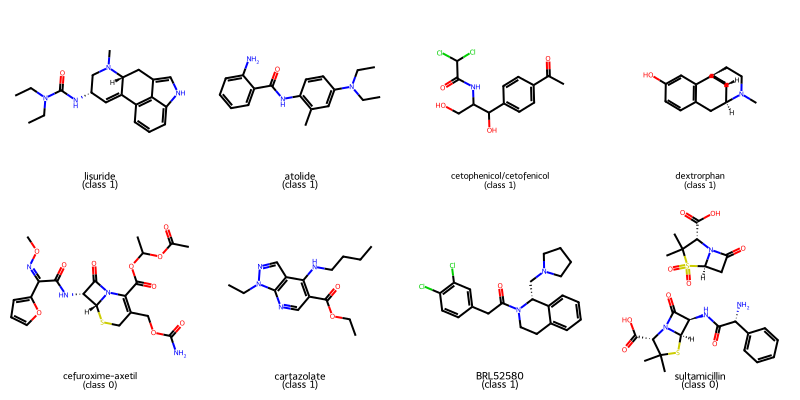

In [ ]:
# Visualiseer een paar moleculen 
sample = df[df['valid']].sample(8, random_state=42)
mols = [Chem.MolFromSmiles(s) for s in sample['smiles']]
labels = [f"{name}\n(class {p})" 
          for name, p in zip(sample['name'], sample['p_np'])]

img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(200, 200), 
                            legends=labels)
img